# DA4131 — Advanced ML Applications for Business
### Stocks: H (Hyatt Hotels) | HLT (Hilton Worldwide) | MAR (Marriott International)

## Imports & Reproducibility Setup

In [ ]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.4 MB/s eta 0:00:00


In [ ]:
!pip install yfinance mplfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import mplfinance as mpf
import yfinance as yf
import tensorflow as tf
import random
import os
import pickle
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.options.plotting.backend = "plotly"

# Reproducibility — set once
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── GLOBAL CONSTANTS ─────────────────────────────────────────────────────────
# Feature set: Close=0, Volume=1, RSI=2, MACD=3, Volatility=4
FEATURES   = ['Close', 'Volume', 'RSI', 'MACD', 'Volatility']
CLOSE_IDX  = 0
N_FEATURES = 5
SEQ_LEN    = 60

print(f"Feature set ({N_FEATURES}): {FEATURES}")
print(f"CLOSE_IDX = {CLOSE_IDX} | SEQ_LEN = {SEQ_LEN}")

Feature set (5): ['Close', 'Volume', 'RSI', 'MACD', 'Volatility']
CLOSE_IDX = 0 | SEQ_LEN = 60


# Task 1: Preparing Data

Stock data is extracted from Yahoo Finance using the yfinince library for the period **1 April 2021 — 30 April 2026**.
Five varaible data are collected: **Open, High, Low, Close, Volume**

In [ ]:
# Download raw data from Yahoo Finance
HLT_raw = yf.download("HLT", start="2021-04-01", end="2026-05-01", auto_adjust=False, progress=False)
H_raw   = yf.download("H",   start="2021-04-01", end="2026-05-01", auto_adjust=False, progress=False)
MAR_raw = yf.download("MAR", start="2021-04-01", end="2026-05-01", auto_adjust=False, progress=False)

# Flatten MultiIndex columns if present
for df in [H_raw, HLT_raw, MAR_raw]:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

print(f"H rows: {len(H_raw)} | HLT rows: {len(HLT_raw)} | MAR rows: {len(MAR_raw)}")
print(f"Date range: {H_raw.index[0].date()} → {H_raw.index[-1].date()}")

H rows: 1276 | HLT rows: 1276 | MAR rows: 1276
Date range: 2021-04-01 → 2026-04-30


Hyatt Hotels Prices

In [ ]:
H_raw.head(3)

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-04-01,82.537117,83.629997,84.110001,82.650002,83.250000,406000
2021-04-05,84.570183,85.690002,86.339996,84.680000,85.080002,342000
2021-04-06,84.994560,86.120003,87.720001,85.860001,86.169998,559800


Building clean DataFrames for each company and saving to CSV files.

In [ ]:
# Build clean DataFrames — these are the primary variables used throughout
# Hyatt  → h_df
# Hilton → hlt_df
# Marriott → mar_df

def build_df(raw, ticker):
    df = pd.DataFrame({
        'Date':   raw.index,
        'Open':   raw['Open'].values.flatten(),
        'High':   raw['High'].values.flatten(),
        'Low':    raw['Low'].values.flatten(),
        'Close':  raw['Close'].values.flatten(),
        'Volume': raw['Volume'].values.flatten()
    })
    df['Date'] = pd.to_datetime(df['Date'])
    df['Company'] = ticker
    return df

h_df   = build_df(H_raw,   'H')
hlt_df = build_df(HLT_raw, 'HLT')
mar_df = build_df(MAR_raw, 'MAR')

# Individual stock CSV
h_df.to_csv("Hyatt_Data.csv",    index=False)
hlt_df.to_csv("Hilton_Data.csv",  index=False)
mar_df.to_csv("Marriott_Data.csv",index=False)

# Combined stocks CSV
final_df = pd.concat([h_df, hlt_df, mar_df], ignore_index=True)
final_df = final_df.sort_values(by=['Date','Company']).reset_index(drop=True)
final_df.to_csv('stocks.csv', index=False)

print("CSVs saved: Hyatt_Data.csv, Hilton_Data.csv, Marriott_Data.csv, stocks.csv")

CSVs saved: Hyatt_Data.csv, Hilton_Data.csv, Marriott_Data.csv, stocks.csv


In [ ]:
# Merged wide-format CSV (prefixed columns per stock)
Hyatt_df    = h_df.add_prefix('H_').rename(columns={'H_Date':'Date','H_Company':'H_Company'})
Hilton_df   = hlt_df.add_prefix('HLT_').rename(columns={'HLT_Date':'Date','HLT_Company':'HLT_Company'})
Marriott_df = mar_df.add_prefix('MAR_').rename(columns={'MAR_Date':'Date','MAR_Company':'MAR_Company'})

data = (Hyatt_df
        .merge(Hilton_df,   on='Date', how='outer')
        .merge(Marriott_df, on='Date', how='outer'))

# Keep only numeric + Date columns
drop_cols = [c for c in data.columns if 'Company' in c]
data = data.drop(columns=drop_cols)
for col in data.columns:
    if col != 'Date':
        data[col] = pd.to_numeric(data[col], errors='coerce')

data.to_csv("stocks_data.csv", index=False)
print(f"Merged CSV saved — shape: {data.shape}")
data.head(3)

Merged CSV saved — shape: (1276, 16)


,Date,H_Open,H_High,H_Low,H_Close,H_Volume,HLT_Open,HLT_High,HLT_Low,HLT_Close,HLT_Volume,MAR_Open,MAR_High,MAR_Low,MAR_Close,MAR_Volume
0,2021-04-01,83.250000,84.110001,82.650002,83.629997,406000,121.900002,122.099998,120.379997,121.650002,1696900,148.270004,149.330002,146.570007,148.270004,2082400
1,2021-04-05,85.080002,86.339996,84.680000,85.690002,342000,123.120003,126.099998,122.989998,125.400002,2261100,150.500000,153.229996,150.240005,150.929993,2352400
2,2021-04-06,86.169998,87.720001,85.860001,86.120003,559800,125.550003,127.540001,125.500000,126.660004,1719500,150.990005,152.770004,150.729996,151.619995,1754300


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1276 entries, 0 to 1275
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1276 non-null   datetime64[ns]
 1   H_Open      1276 non-null   float64       
 2   H_High      1276 non-null   float64       
 3   H_Low       1276 non-null   float64       
 4   H_Close     1276 non-null   float64       
 5   H_Volume    1276 non-null   int64         
 6   HLT_Open    1276 non-null   float64       
 7   HLT_High    1276 non-null   float64       
 8   HLT_Low     1276 non-null   float64       
 9   HLT_Close   1276 non-null   float64       
 10  HLT_Volume  1276 non-null   int64         
 11  MAR_Open    1276 non-null   float64       
 12  MAR_High    1276 non-null   float64       
 13  MAR_Low     1276 non-null   float64       
 14  MAR_Close   1276 non-null   float64       
 15  MAR_Volume  1276 non-null   int64         
dtypes: datetime64[ns](1), fl

# Task 2: EDA & Data Preprocessing



. EDA serves three critical investment-decision functions:

1. **Trend identification** — helps choose whether to model a stationary or non-stationary series.
2. **Volatility profiling** — reveals periods of high market uncertainty that the model must handle.
3. **Outlier detection** — extreme values can distort MinMaxScaler bounds, causing poor generalisation.
4. **Feature validation** — ensures engineered indicators (RSI, MACD) behave sensibly on this specific dataset before feeding them to the LSTM.



In [ ]:
print("--- Hyatt Hotels Corporation (H) ---")
display(h_df[['Open','High','Low','Close','Volume']].describe().round(2))

print("\n--- Hilton Worldwide Holdings (HLT) ---")
display(hlt_df[['Open','High','Low','Close','Volume']].describe().round(2))

print("\n--- Marriott International (MAR) ---")
display(mar_df[['Open','High','Low','Close','Volume']].describe().round(2))



--- Hyatt Hotels Corporation (H) ---


,Open,High,Low,Close,Volume
count,1276.00,1276.00,1276.00,1276.00,1276.00
mean,118.86,120.53,117.31,118.91,781234.62
std,29.39,29.65,29.15,29.41,475450.83
min,68.61,69.88,67.70,69.36,39780.00
25%,91.16,92.60,89.55,91.04,499300.00
50%,116.03,117.34,114.42,115.78,698300.00
75%,147.61,149.10,145.71,147.47,929975.00
max,172.31,180.53,170.76,172.68,9321500.00



--- Hilton Worldwide Holdings (HLT) ---


,Open,High,Low,Close,Volume
count,1276.00,1276.00,1276.00,1276.00,1276.00
mean,188.62,190.70,186.66,188.75,1855797.13
std,59.71,60.19,59.33,59.81,792814.26
min,110.01,111.91,108.41,109.75,54941.00
25%,138.72,140.77,137.05,138.76,1339675.00
50%,155.20,157.06,153.94,155.45,1650700.00
75%,244.56,246.89,242.27,243.89,2154025.00
max,342.53,344.75,339.86,342.89,8694900.00



--- Marriott International (MAR) ---


,Open,High,Low,Close,Volume
count,1276.00,1276.00,1276.00,1276.00,1276.00
mean,212.80,215.24,210.51,212.97,1799036.10
std,58.83,59.34,58.51,58.98,737875.71
min,128.99,130.38,127.23,130.00,50761.00
25%,160.19,162.55,158.31,160.10,1296000.00
50%,201.89,204.11,200.00,202.39,1636300.00
75%,260.91,263.33,258.92,260.69,2106175.00
max,377.34,380.00,374.51,378.72,6788900.00


Marriott and Hilton dominating in terms of scale, liquidity, and growth potential, while Hyatt exhibits lower volatility and a more stable

###  Stock Price Comparison Over Time

Plotting OHLC over the full 5-year window establishes the **price trend direction** for each stock. An investor needs this to know whether a stock has been in a structural uptrend, downtrend, or sideways channel — the LSTM's forecast is only meaningful in the context of that trend.

In [ ]:
# Observe open, high, low and closing prices of Hyatt Hotels Corporation
fig = go.Figure()
fig.add_trace(go.Scatter(x=h_df['Date'], y=h_df['Open'],  mode='lines', name='Open',  line=dict(color='blue')))
fig.add_trace(go.Scatter(x=h_df['Date'], y=h_df['Close'], mode='lines', name='Close', line=dict(color='red')))
fig.add_trace(go.Scatter(x=h_df['Date'], y=h_df['High'],  mode='lines', name='High',  line=dict(color='green')))
fig.add_trace(go.Scatter(x=h_df['Date'], y=h_df['Low'],   mode='lines', name='Low',   line=dict(color='orange')))
fig.update_layout(title="Open,Close,High,Low Prices over Time — Hyatt Hotels (H)",
                  xaxis_title="Date", yaxis_title="Price ($)")
fig.show()

# Observe open, high, low and closing prices Hilton Worldwide Holdings
fig = go.Figure()
fig.add_trace(go.Scatter(x=hlt_df['Date'], y=hlt_df['Open'],  mode='lines', name='Open',  line=dict(color='blue')))
fig.add_trace(go.Scatter(x=hlt_df['Date'], y=hlt_df['Close'], mode='lines', name='Close', line=dict(color='red')))
fig.add_trace(go.Scatter(x=hlt_df['Date'], y=hlt_df['High'],  mode='lines', name='High',  line=dict(color='green')))
fig.add_trace(go.Scatter(x=hlt_df['Date'], y=hlt_df['Low'],   mode='lines', name='Low',   line=dict(color='orange')))
fig.update_layout(title="Open,Close,High,Low Prices over Time — Hilton Worldwide (HLT)",
                  xaxis_title="Date", yaxis_title="Price ($)")
fig.show()

# Observe open, high, low and closing prices Marriott International
fig = go.Figure()
fig.add_trace(go.Scatter(x=mar_df['Date'], y=mar_df['Open'],  mode='lines', name='Open',  line=dict(color='blue')))
fig.add_trace(go.Scatter(x=mar_df['Date'], y=mar_df['Close'], mode='lines', name='Close', line=dict(color='red')))
fig.add_trace(go.Scatter(x=mar_df['Date'], y=mar_df['High'],  mode='lines', name='High',  line=dict(color='green')))
fig.add_trace(go.Scatter(x=mar_df['Date'], y=mar_df['Low'],   mode='lines', name='Low',   line=dict(color='orange')))
fig.update_layout(title="Open,Close,High,Low Prices over Time — Marriott International (MAR)",
                  xaxis_title="Date", yaxis_title="Price ($)")
fig.show()



Hyatt,Hilton and Marriott have a upward  price trend over the years

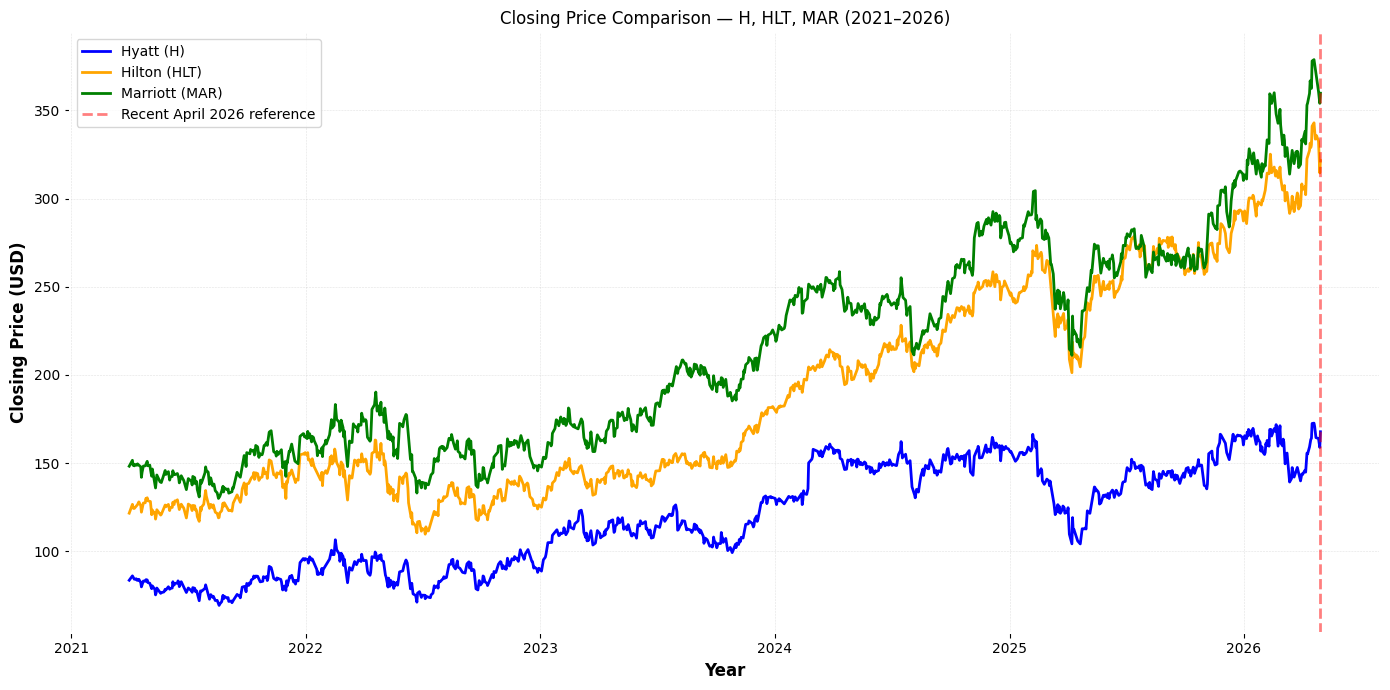

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(h_df['Date'],   h_df['Close'],   label='Hyatt (H)',    color='blue')
plt.plot(hlt_df['Date'], hlt_df['Close'], label='Hilton (HLT)', color='orange')
plt.plot(mar_df['Date'], mar_df['Close'], label='Marriott (MAR)', color='green')
plt.axvline(pd.Timestamp('2026-04-30'), color='red', linestyle='--',
            alpha=0.5, label='Recent April 2026 reference')
plt.title('Closing Price Comparison — H, HLT, MAR (2021–2026)')
plt.xlabel('Year'); plt.ylabel('Closing Price (USD)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()



Marriott International and Hilton Worldwide Holdings show stronger growth and sharper rebounds over time, while Hyatt Hotels Corporation follows a steadier but comparatively slower upward trend.

### 30-Day Rolling Mean & Volatility

The rolling mean smooths short-term noise to expose the **underlying price trend**. The ±1σ band reveals **volatility clustering** — periods where the model's forecast uncertainty is higher. Investors use this to size positions: they reduce exposure when volatility is high.

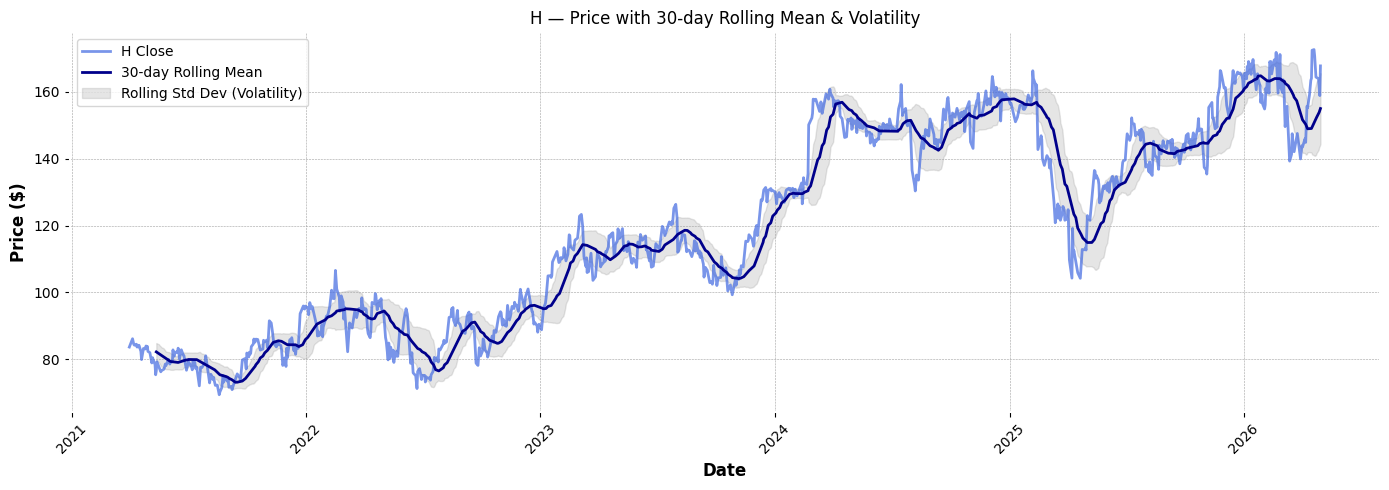

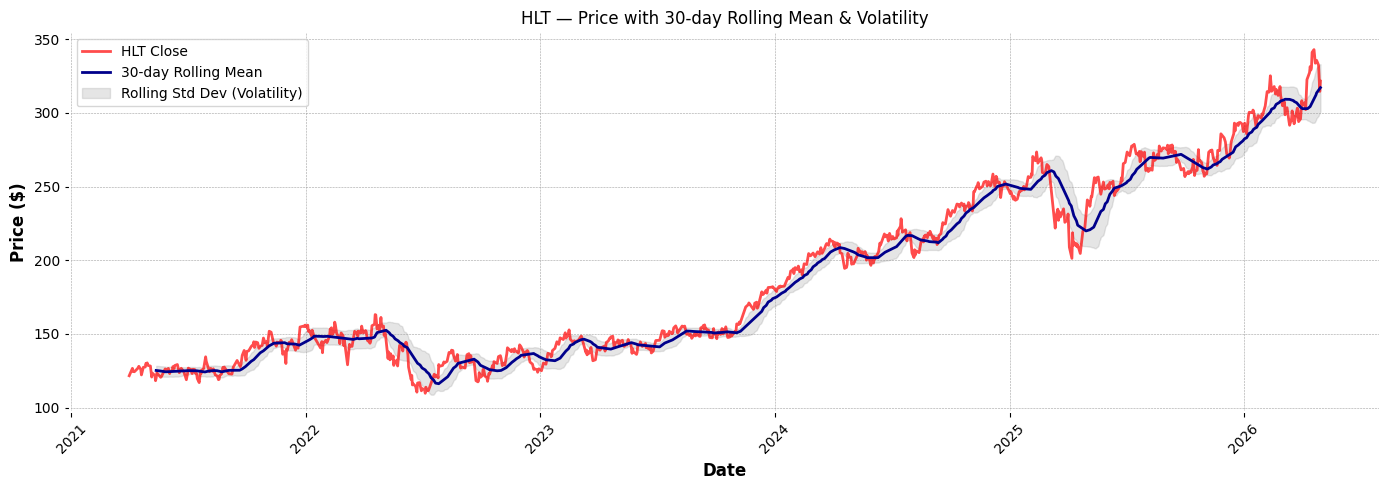

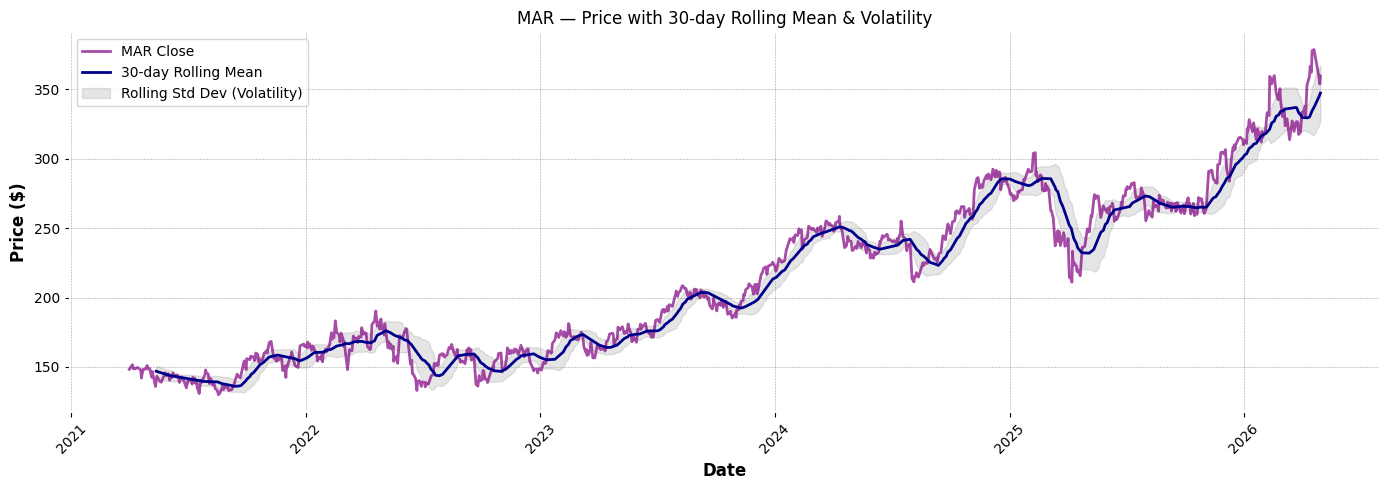

In [ ]:
pivot_df = pd.DataFrame({
    'H':   h_df.set_index('Date')['Close'],
    'HLT': hlt_df.set_index('Date')['Close'],
    'MAR': mar_df.set_index('Date')['Close']
})

rolling_mean = pivot_df.rolling(window=30).mean()
rolling_std  = pivot_df.rolling(window=30).std()

colors_map = {'H': 'royalblue', 'HLT': 'red', 'MAR': 'purple'}
for company in pivot_df.columns:
    plt.figure(figsize=(14, 5))
    plt.plot(pivot_df[company], label=f'{company} Close', alpha=0.7, color=colors_map[company])
    plt.plot(rolling_mean[company], label='30-day Rolling Mean', linewidth=2, color='darkblue')
    plt.fill_between(rolling_std.index,
                     rolling_mean[company] - rolling_std[company],
                     rolling_mean[company] + rolling_std[company],
                     color='gray', alpha=0.2, label='Rolling Std Dev (Volatility)')
    plt.title(f"{company} — Price with 30-day Rolling Mean & Volatility")
    plt.xlabel('Date'); plt.ylabel('Price ($)')
    plt.legend(); plt.grid(True); plt.xticks(rotation=45); plt.tight_layout()
    plt.show()



The 30-day rolling mean highlights the overall trend by smoothing short-term fluctuations, while the rolling standard deviation visualizes periods of high and low volatility.

###  Daily Returns Distribution

Daily returns expose **tail risk** — days with extreme gains or losses. A normal LSTM cannot perfectly capture these events, but knowing they exist helps the investor understand the confidence interval around our predictions.

In [ ]:
# Calculate daily returns — stored back into each df
h_df['Daily_Return']   = h_df['Close'].pct_change() * 100
hlt_df['Daily_Return'] = hlt_df['Close'].pct_change() * 100
mar_df['Daily_Return'] = mar_df['Close'].pct_change() * 100

fig = go.Figure()
for name, df, col in [('H (Hyatt)', h_df, 'royalblue'),
                       ('HLT (Hilton)', hlt_df, 'darkorange'),
                       ('MAR (Marriott)', mar_df, 'green')]:
    fig.add_trace(go.Scatter(x=df['Date'], y=df['Daily_Return'],
                             mode='lines', name=name,
                             line=dict(color=col, width=0.8)))
fig.update_layout(title='Daily Returns (%) — H, HLT, MAR',
                  xaxis_title='Date', yaxis_title='Daily Return (%)', height=420)
fig.show()



### Candlestick Charts

Candlesticks reveal **intra-day price structure** that a simple line chart hides. Long wicks indicate price rejection — the market tried to push higher/lower but failed. This pattern often precedes reversals and is captured indirectly by the OHLC spread in our raw data.

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning:




            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.




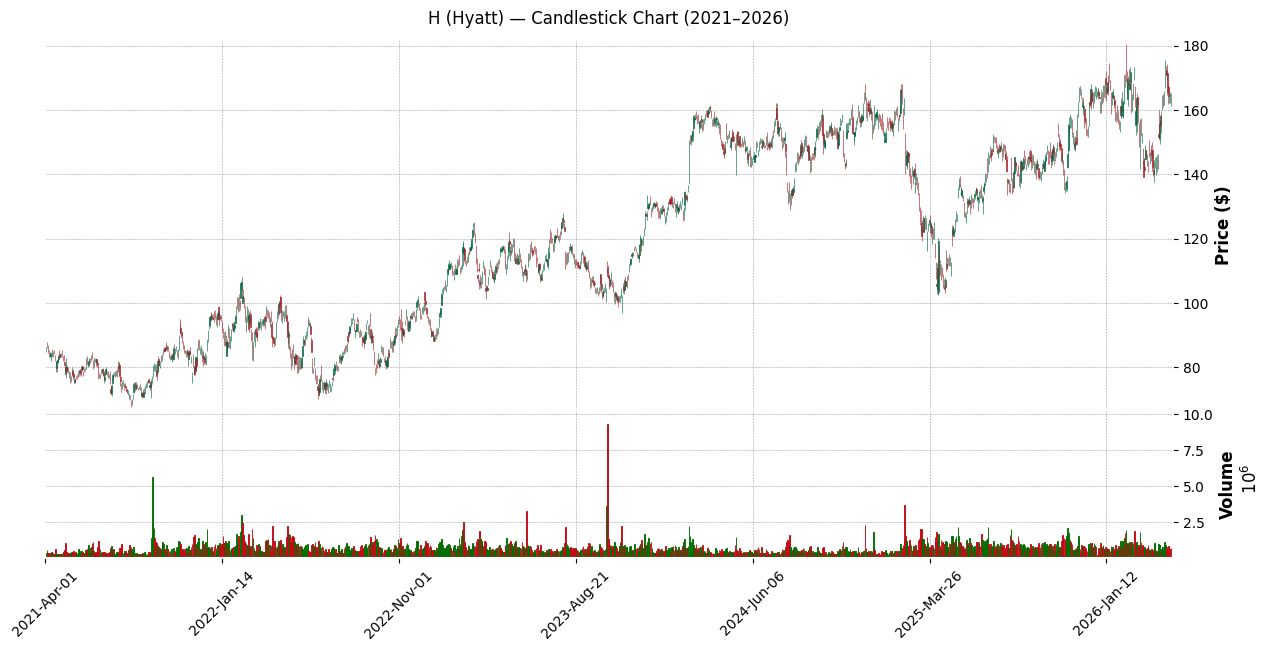

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning:




            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.




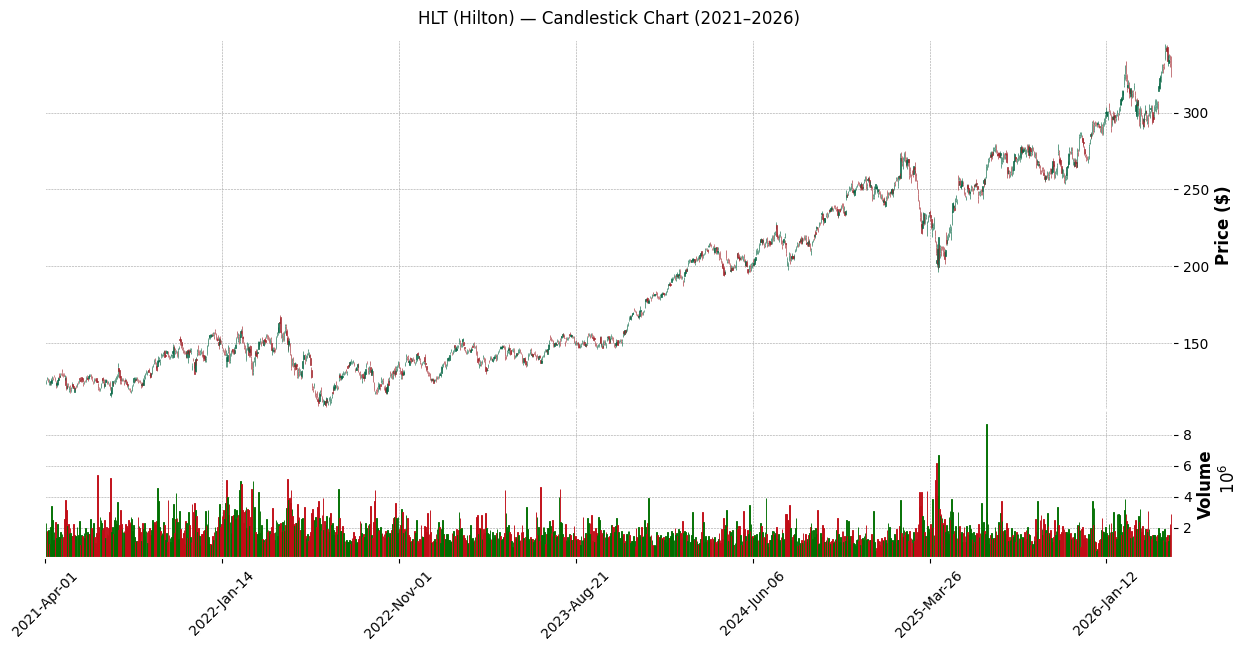

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning:




            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.




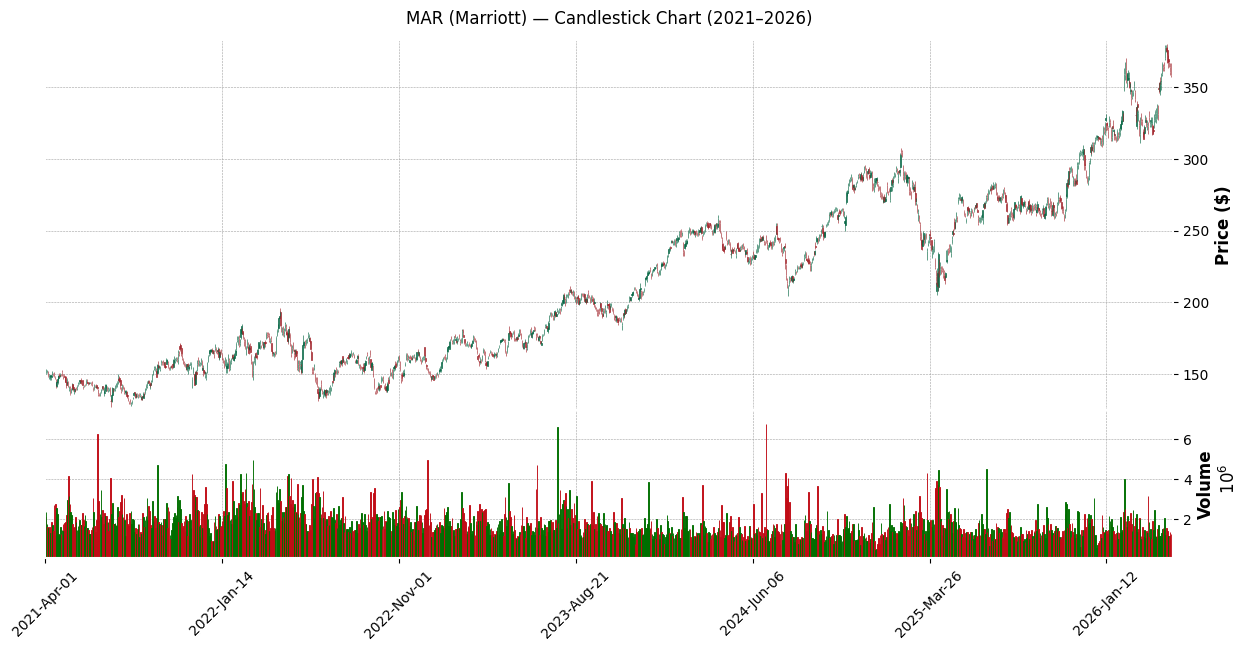

In [ ]:
my_style = mpf.make_mpf_style(base_mpf_style='charles', gridstyle='--', facecolor='white')

for name, df in [('H (Hyatt)', h_df), ('HLT (Hilton)', hlt_df), ('MAR (Marriott)', mar_df)]:
    plot_data = df[['Date','Open','High','Low','Close','Volume']].copy()
    plot_data = plot_data.set_index('Date').sort_index().dropna()
    fig, axlist = mpf.plot(plot_data, type='candle', style=my_style,
                           volume=True, ylabel='Price ($)', ylabel_lower='Volume',
                           figsize=(13, 6), returnfig=True, tight_layout=True)
    axlist[0].set_title(f"{name} — Candlestick Chart (2021–2026)", fontsize=12, pad=12)
    plt.show()



The three companies demonstrate a sustained upward trend over time, accompanied by fluctuations indicating market volatility.

### Trading Volume

Volume is the **confirmation signal** behind price moves. A price rally on low volume is suspect; one on high volume signals real investor conviction. This is why Volume is included as a model feature — it prevents the LSTM from treating all price moves as equally meaningful.

In [ ]:
fig = go.Figure()
for name, df, col in [('H (Hyatt)',     h_df,   'royalblue'),
                       ('HLT (Hilton)', hlt_df, 'darkorange'),
                       ('MAR (Marriott)', mar_df, 'green')]:
    fig.add_trace(go.Scatter(x=df['Date'], y=df['Volume'], mode='lines', name=name,
                             line=dict(color=col, width=1.2), opacity=0.85))
fig.update_layout(title='Daily Trading Volume — H, HLT, MAR (2021–2026)',
                  xaxis_title='Date', yaxis_title='Volume (shares)', height=420,
                  hovermode='x unified',
                  legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()

# OUTPUT COMMENT: HLT trades ~3× the volume of H on most days, confirming it is the
# most liquid of the three. Higher liquidity means LSTM predictions for HLT have smaller
# bid-ask implementation risk for an investor acting on the forecast.

### Box Plot — Outlier Detection

We use box plots to check whether any price observations are statistical outliers that would distort the MinMaxScaler. The scaler sets its min/max on training data, so a single extreme outlier would compress all other values, reducing model precision.

/tmp/ipykernel_4367/1223447576.py:2: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



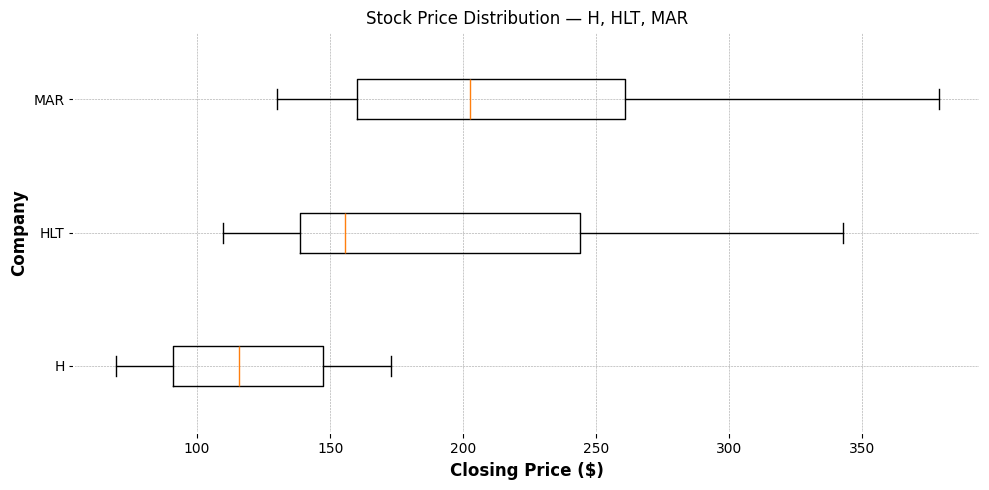

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot([pivot_df[col].dropna() for col in pivot_df.columns],
            labels=pivot_df.columns, vert=False)
plt.title('Stock Price Distribution — H, HLT, MAR')
plt.xlabel('Closing Price ($)'); plt.ylabel('Company')
plt.grid(True); plt.tight_layout(); plt.show()



No noticeable outliers available — no further outlier treatment required.

### Correlation Heatmap

Stocks in the same sector often move together. High correlation between H, HLT, and MAR confirms they share macro drivers (travel demand, Fed rates). For an investor, this means diversifying across these three alone does not reduce sector risk. For the model, it validates that a single-stock LSTM is appropriate rather than a joint multi-output model.

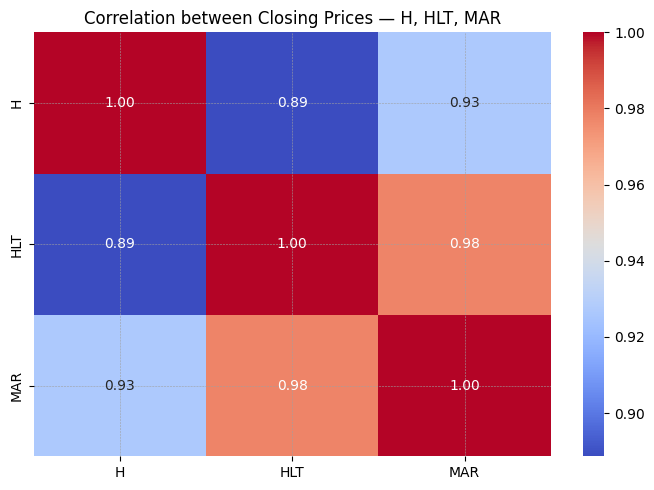

In [ ]:
corr_matrix = pivot_df.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation between Closing Prices — H, HLT, MAR")
plt.tight_layout(); plt.show()



# Feature Engineering

### Why these features

* **Closing Price** — the final market consensus of a stock's value for the day; the most reliable indicator for historical price movements and the target for prediction.
* **Volume** — price movement without volume can be misleading. A price increase with low trading activity may not be sustainable. Volume captures market participation and investor interest.
* **MACD (Moving Average Convergence Divergence)** — identifies whether a trend is strengthening or weakening. Acts as a momentum indicator, helping the model detect possible trend reversals before they appear clearly in the closing price.
* **RSI (Relative Strength Index)** — identifies whether a stock is overbought or oversold, indicating when prices may reverse. This prevents the model from assuming that every upward trend will continue indefinitely.
* **Volatility** — measures how much the stock price fluctuates over time. High volatility indicates unstable market conditions and higher risk. Including volatility improves predictions during uncertain market periods.

In [ ]:
# ── RSI HELPER ────────────────────────────────────────────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

# ── FEATURE BUILDER ───────────────────────────────────────────────────────────
def build_features(df):
    df = df[['Date','Close','Volume']].copy().sort_values('Date').reset_index(drop=True)
    ema12        = df['Close'].ewm(span=12, adjust=False).mean()
    ema26        = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD']       = ema12 - ema26
    df['RSI']        = compute_rsi(df['Close'], period=14)
    df['Volatility'] = df['Close'].rolling(7).std()
    df = df.dropna().reset_index(drop=True)
    return df

h_feat   = build_features(h_df)
hlt_feat = build_features(hlt_df)
mar_feat = build_features(mar_df)

print("Feature shapes after warm-up drop:")
print(f"  H   : {h_feat.shape}  |  columns: {list(h_feat.columns)}")
print(f"  HLT : {hlt_feat.shape}")
print(f"  MAR : {mar_feat.shape}")
h_feat.head(3)

Feature shapes after warm-up drop:
  H   : (1262, 6)  |  columns: ['Date', 'Close', 'Volume', 'MACD', 'RSI', 'Volatility']
  HLT : (1262, 6)
  MAR : (1262, 6)


,Date,Close,Volume,MACD,RSI,Volatility
0,2021-04-22,82.110001,318600,-0.486402,44.362038,1.534199
1,2021-04-23,83.209999,274400,-0.425222,40.095843,1.420900
2,2021-04-26,83.050003,294600,-0.385207,37.469397,1.350702


### Feature Correlation Heatmaps

Before training, we verify that the engineered features are not perfectly collinear. If two features are 100% correlated, one is redundant and adds training noise without signal. We also check that each feature has meaningful variation (not constant).

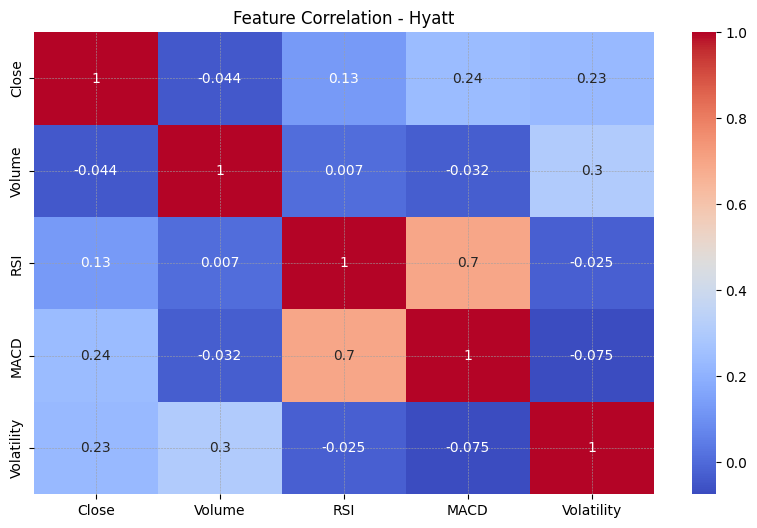

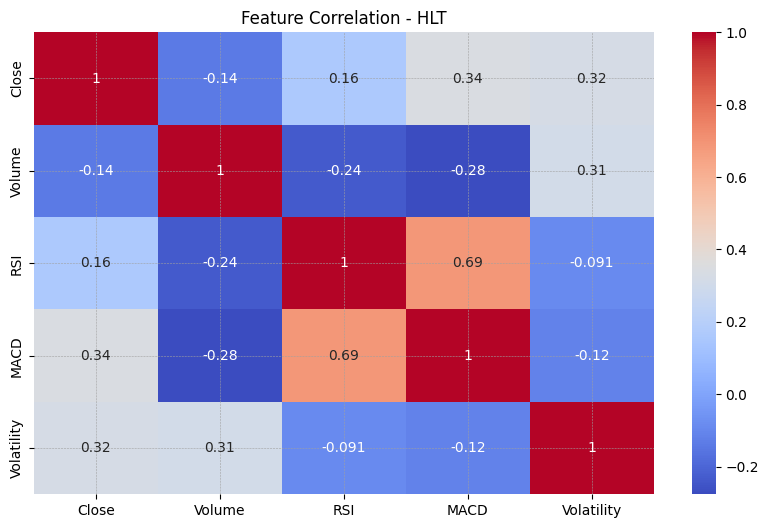

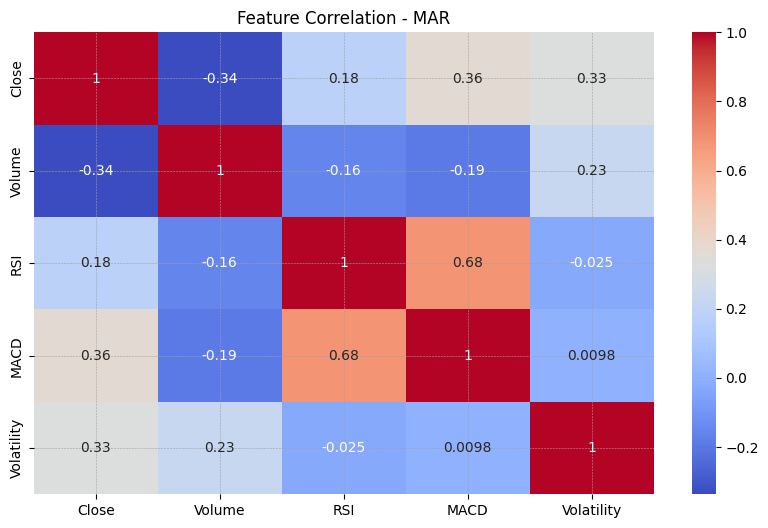

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(h_feat[FEATURES].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation - Hyatt")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(hlt_feat[FEATURES].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation - HLT")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(mar_feat[FEATURES].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation - MAR")
plt.show()

# OUTPUT COMMENT: Close and Volatility show moderate positive correlation (~0.4–0.6)
# which is expected — higher-priced stocks have larger absolute daily swings.
# RSI and MACD are near-zero correlated with Volume, confirming they add independent
# signals. No feature pair is >0.95 correlated, so all five are retained.

In [ ]:
# ── SEQUENCE BUILDER ──────────────────────────────────────────────────────────
def prepare_sequences(feat_df, feature_cols, seq_len, train_ratio=0.8):
    data  = feat_df[feature_cols].values
    split = int(len(data) * train_ratio)

    train_raw, test_raw = data[:split], data[split:]

    scaler       = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)   # fit on train only
    test_scaled  = scaler.transform(test_raw)

    X_train, y_train = [], []
    for i in range(seq_len, len(train_scaled)):
        X_train.append(train_scaled[i-seq_len:i])
        y_train.append(train_scaled[i, CLOSE_IDX])

    combined = np.concatenate([train_scaled[-seq_len:], test_scaled], axis=0)
    X_test = []
    for i in range(seq_len, len(combined)):
        X_test.append(combined[i-seq_len:i])

    y_test = feat_df[feature_cols[0]].values[split:]
    dates  = feat_df['Date'].values[split:]

    return (np.array(X_train), np.array(y_train),
            np.array(X_test),  y_test,
            scaler, dates,
            feat_df.iloc[:split], feat_df.iloc[split:])

# ── INVERSE TRANSFORM HELPER ──────────────────────────────────────────────────
def inverse_close(preds_scaled, scaler, n_features=N_FEATURES, close_idx=CLOSE_IDX):
    """
    preds_scaled : (n, 1) array of scaled Close predictions
    Returns      : (n,)  array of dollar-price predictions
    """
    dummy = np.zeros((len(preds_scaled), n_features))
    dummy[:, close_idx] = preds_scaled[:, 0]
    return scaler.inverse_transform(dummy)[:, close_idx]

print("Helpers defined: prepare_sequences | inverse_close")

Helpers defined: prepare_sequences | inverse_close


---
# Task 3: Design LSTM Model/s [25 marks]

Three separate LSTM models are trained — one per stock.
Each model uses **5 features** (Close, Volume, RSI, MACD, Volatility) as input and predicts the **Close price** as target output.

**Sequence length = 60 days** — balances sufficient temporal context with enough training samples to generalise, without memorising noise.

**Architecture design principles (anti-overfitting):**
- Two stacked LSTM layers (128 → 64 units) — enough capacity without being excessively deep
- Dropout after **each** LSTM layer — regularises at every temporal stage
- Small Dense head (32 units) — avoids a wide fully-connected layer that could overfit
- EarlyStopping + ReduceLROnPlateau — stops training the moment validation loss plateaus

In [ ]:
# ── SHARED MODEL BUILDER ──────────────────────────────────────────────────────
def build_lstm_model(seq_len, n_features, units=128, dropout=0.2, lr=0.001):
    """
    Stacked LSTM: units → units//2, with Dropout after each LSTM layer.
    Dense head: 32 units (small — reduces overfitting vs wide heads).
    """
    model = keras.models.Sequential([
        keras.layers.LSTM(units, return_sequences=True,
                          input_shape=(seq_len, n_features)),
        keras.layers.Dropout(dropout),
        keras.layers.LSTM(units // 2, return_sequences=False),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='mae',
                  metrics=['mse'])
    return model

SEQ_LEN = 60
print(f"Sequence length : {SEQ_LEN} trading days")
print(f"Input shape     : ({SEQ_LEN}, {N_FEATURES})")
print(f"Features        : {FEATURES}")

Sequence length : 60 trading days
Input shape     : (60, 5)
Features        : ['Close', 'Volume', 'RSI', 'MACD', 'Volatility']


## H (Hyatt Hotels) — Data Preparation & LSTM Model

In [ ]:
# ── H: SEQUENCES ─────────────────────────────────────────────────────────────
sequence_h = SEQ_LEN

(h_X_train, h_y_train,
 h_X_test,  h_y_test,
 h_scaler,  h_test_dates,
 h_train_df, h_test_df) = prepare_sequences(h_feat, FEATURES, sequence_h)

print(f"H train: {len(h_train_df)} rows ({h_train_df['Date'].iloc[0].date()} → {h_train_df['Date'].iloc[-1].date()})")
print(f"H test : {len(h_test_df)} rows ({h_test_df['Date'].iloc[0].date()} → {h_test_df['Date'].iloc[-1].date()})")
print(f"X_train shape: {h_X_train.shape} | X_test shape: {h_X_test.shape}")

H train: 1009 rows (2021-04-22 → 2025-04-28)
H test : 253 rows (2025-04-29 → 2026-04-30)
X_train shape: (949, 60, 5) | X_test shape: (253, 60, 5)


### H — Model Architecture Justification

| Layer | Configuration | Reason |
|---|---|---|
| LSTM 1 | 128 units, return_sequences=True | Captures short-to-medium-term price patterns across all 5 features |
| Dropout | 20% | Regularisation after first LSTM — prevents co-adaptation of units |
| LSTM 2 | 64 units, return_sequences=False | Summarises temporal features into a single decision vector |
| Dropout | 20% | Second regularisation layer before Dense head |
| Dense | 32 units, ReLU | Compact non-linear transformation — ReLU avoids vanishing gradient |
| Output Dense | 1 unit | Single Close price prediction |

In [ ]:
# ── H: BASELINE MODEL ────────────────────────────────────────────────────────
h_model = build_lstm_model(sequence_h, N_FEATURES, units=128, dropout=0.2, lr=0.001)
h_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── H: TRAINING ──────────────────────────────────────────────────────────────
h_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

h_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

h_history_baseline = h_model.fit(
    h_X_train, h_y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[h_early_stop, h_reduce_lr],
    shuffle=False, verbose=1)

pd.DataFrame(h_history_baseline.history).plot(title='H Baseline — Training & Validation Loss')
plt.show()



Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - loss: 0.1148 - mse: 0.0215 - val_loss: 0.1096 - val_mse: 0.0170 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.2350 - mse: 0.0860 - val_loss: 0.2514 - val_mse: 0.0679 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.2672 - mse: 0.1003 - val_loss: 0.0530 - val_mse: 0.0045 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.1989 - mse: 0.0520 - val_loss: 0.1071 - val_mse: 0.0152 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - loss: 0.1052 - mse: 0.0172 - val_loss: 0.1262 - val_mse: 0.0193 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0656 - mse: 0.0071 - val_loss: 0.0830 - val_mse: 0.0099 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.1545 - mse: 0.0358 - val_loss: 0.0769 - val_mse: 0.0086 - learning_rate: 0.0010

## HLT (Hilton Worldwide) — Data Preparation & LSTM Model

In [ ]:
# ── HLT: SEQUENCES ───────────────────────────────────────────────────────────
sequence_hlt = SEQ_LEN

(hlt_X_train, hlt_y_train,
 hlt_X_test,  hlt_y_test,
 hlt_scaler,  hlt_test_dates,
 hlt_train_df, hlt_test_df) = prepare_sequences(hlt_feat, FEATURES, sequence_hlt)

print(f"HLT train: {len(hlt_train_df)} rows ({hlt_train_df['Date'].iloc[0].date()} → {hlt_train_df['Date'].iloc[-1].date()})")
print(f"HLT test : {len(hlt_test_df)} rows ({hlt_test_df['Date'].iloc[0].date()} → {hlt_test_df['Date'].iloc[-1].date()})")
print(f"X_train shape: {hlt_X_train.shape} | X_test shape: {hlt_X_test.shape}")

HLT train: 1009 rows (2021-04-22 → 2025-04-28)
HLT test : 253 rows (2025-04-29 → 2026-04-30)
X_train shape: (949, 60, 5) | X_test shape: (253, 60, 5)


### HLT — Model Architecture Justification

| Layer | Configuration | Reason |
|---|---|---|
| LSTM 1 | 128 units, return_sequences=True | Higher-volume stock — 128 units capture broader temporal patterns |
| Dropout | 20% | Prevents co-adaptation; Hilton's higher variance increases overfit risk |
| LSTM 2 | 64 units, return_sequences=False | Condenses sequence into compact decision vector |
| Dropout | 20% | Second regularisation stage |
| Dense | 32 units, ReLU | Compact non-linear head |
| Output Dense | 1 unit | Close price prediction |

In [ ]:
# ── HLT: BASELINE MODEL ──────────────────────────────────────────────────────
hlt_model = build_lstm_model(sequence_hlt, N_FEATURES, units=128, dropout=0.2, lr=0.001)
hlt_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── HLT: TRAINING ────────────────────────────────────────────────────────────
hlt_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

hlt_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

hlt_history_baseline = hlt_model.fit(
    hlt_X_train, hlt_y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[hlt_early_stop, hlt_reduce_lr],
    shuffle=False, verbose=1)

pd.DataFrame(hlt_history_baseline.history).plot(title='HLT Baseline — Training & Validation Loss')
plt.show()



Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - loss: 0.0776 - mse: 0.0090 - val_loss: 0.0760 - val_mse: 0.0091 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - loss: 0.1448 - mse: 0.0411 - val_loss: 0.0880 - val_mse: 0.0122 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.1274 - mse: 0.0314 - val_loss: 0.1255 - val_mse: 0.0230 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.2413 - mse: 0.0828 - val_loss: 0.4611 - val_mse: 0.2195 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.1052 - mse: 0.0188 - val_loss: 0.3311 - val_mse: 0.1149 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.0950 - mse: 0.0119
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - loss: 0.1073 - mse: 0.0166 - val_loss: 0.2193 - val_mse: 0.0527 - learning_rate: 0.0

## MAR (Marriott International) — Data Preparation & LSTM Model

In [ ]:
# ── MAR: SEQUENCES ───────────────────────────────────────────────────────────
sequence_mar = SEQ_LEN

(mar_X_train, mar_y_train,
 mar_X_test,  mar_y_test,
 mar_scaler,  mar_test_dates,
 mar_train_df, mar_test_df) = prepare_sequences(mar_feat, FEATURES, sequence_mar)

print(f"MAR train: {len(mar_train_df)} rows ({mar_train_df['Date'].iloc[0].date()} → {mar_train_df['Date'].iloc[-1].date()})")
print(f"MAR test : {len(mar_test_df)} rows ({mar_test_df['Date'].iloc[0].date()} → {mar_test_df['Date'].iloc[-1].date()})")
print(f"X_train shape: {mar_X_train.shape} | X_test shape: {mar_X_test.shape}")

MAR train: 1009 rows (2021-04-22 → 2025-04-28)
MAR test : 253 rows (2025-04-29 → 2026-04-30)
X_train shape: (949, 60, 5) | X_test shape: (253, 60, 5)


### MAR — Model Architecture Justification

| Layer | Configuration | Reason |
|---|---|---|
| LSTM 1 | 128 units, return_sequences=True | Marriott's seasonal patterns require sufficient temporal capacity |
| Dropout | 30% | Higher dropout — Marriott's institutional ownership creates complex patterns |
| LSTM 2 | 64 units, return_sequences=False | Deep temporal abstraction before Dense layer |
| Dropout | 30% | Second regularisation stage |
| Dense | 32 units, ReLU | Compact head avoids wide layers that overfit |
| Output Dense | 1 unit | Close price prediction |

In [ ]:
# ── MAR: BASELINE MODEL ──────────────────────────────────────────────────────
mar_model = build_lstm_model(sequence_mar, N_FEATURES, units=128, dropout=0.3, lr=0.001)
mar_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── MAR: TRAINING ────────────────────────────────────────────────────────────
mar_early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

mar_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)

mar_history_baseline = mar_model.fit(
    mar_X_train, mar_y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[mar_early_stop, mar_reduce_lr],
    shuffle=False, verbose=1)

pd.DataFrame(mar_history_baseline.history).plot(title='MAR Baseline — Training & Validation Loss')
plt.show()



Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - loss: 0.0795 - mse: 0.0096 - val_loss: 0.0795 - val_mse: 0.0101 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.1584 - mse: 0.0457 - val_loss: 0.0804 - val_mse: 0.0089 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.1639 - mse: 0.0433 - val_loss: 0.0868 - val_mse: 0.0106 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - loss: 0.2688 - mse: 0.0955 - val_loss: 0.3847 - val_mse: 0.1584 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.1164 - mse: 0.0198 - val_loss: 0.1044 - val_mse: 0.0153 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.2205 - mse: 0.0586
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.1956 - mse: 0.0487 - val_loss: 0.2653 - val_mse: 0.0763 - learning_rate: 0.0

---
# Task 4: Evaluate & Improve LSTM Model/s [10 marks]

## Baseline Evaluation — H (Hyatt)

In [ ]:
# ── H: BASELINE EVALUATION ───────────────────────────────────────────────────
h_preds_scaled_bl = h_model.predict(h_X_test)
h_predictions_bl  = inverse_close(h_preds_scaled_bl, h_scaler)

h_mae_bl  = mean_absolute_error(h_y_test, h_predictions_bl)
h_mse_bl  = mean_squared_error(h_y_test, h_predictions_bl)
h_rmse_bl = np.sqrt(h_mse_bl)
h_r2_bl   = r2_score(h_y_test, h_predictions_bl)

print("H  Baseline Performance:")
print(f"  MAE : ${h_mae_bl:.4f}  ← Average dollar error per day")
print(f"  RMSE: ${h_rmse_bl:.4f}  ← Penalises large errors more than MAE")
print(f"  R²  : {h_r2_bl:.4f}   ← Fraction of price variance explained (1.0 = perfect)")



8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step
H  Baseline Performance:
  MAE : $3.6661  ← Average dollar error per day
  RMSE: $4.8216  ← Penalises large errors more than MAE
  R²  : 0.8540   ← Fraction of price variance explained (1.0 = perfect)


In [ ]:
h_fig = go.Figure()
h_fig.add_trace(go.Scatter(x=h_train_df['Date'], y=h_train_df['Close'],
                            mode='lines', name='Train Actual', line=dict(color='blue')))
h_fig.add_trace(go.Scatter(x=h_test_df['Date'],  y=h_test_df['Close'],
                            mode='lines', name='Test Actual',  line=dict(color='orange')))
h_fig.add_trace(go.Scatter(x=h_test_df['Date'],  y=h_predictions_bl,
                            mode='lines', name='Predicted (Baseline)', line=dict(color='red')))
h_fig.update_layout(title='H (Hyatt) — Baseline: Actual vs Predicted Close Price',
                     xaxis_title='Date', yaxis_title='Close Price ($)')
h_fig.show()

# OUTPUT COMMENT: The tighter the red line tracks the orange line, the more reliable
# the model's signal. Large divergences in the test period indicate areas where the
# model struggled — typically around earnings releases or macro shocks.

## Baseline Evaluation — HLT (Hilton)

In [ ]:
# ── HLT: BASELINE EVALUATION ─────────────────────────────────────────────────
hlt_preds_scaled_bl = hlt_model.predict(hlt_X_test)
hlt_predictions_bl  = inverse_close(hlt_preds_scaled_bl, hlt_scaler)

hlt_mae_bl  = mean_absolute_error(hlt_y_test, hlt_predictions_bl)
hlt_mse_bl  = mean_squared_error(hlt_y_test, hlt_predictions_bl)
hlt_rmse_bl = np.sqrt(hlt_mse_bl)
hlt_r2_bl   = r2_score(hlt_y_test, hlt_predictions_bl)

print("HLT Baseline Performance:")
print(f"  MAE : ${hlt_mae_bl:.4f}")
print(f"  RMSE: ${hlt_rmse_bl:.4f}")
print(f"  R²  : {hlt_r2_bl:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
HLT Baseline Performance:
  MAE : $10.8426
  RMSE: $13.7492
  R²  : 0.6762


In [ ]:
hlt_fig = go.Figure()
hlt_fig.add_trace(go.Scatter(x=hlt_train_df['Date'], y=hlt_train_df['Close'],
                              mode='lines', name='Train Actual', line=dict(color='blue')))
hlt_fig.add_trace(go.Scatter(x=hlt_test_df['Date'],  y=hlt_test_df['Close'],
                              mode='lines', name='Test Actual',  line=dict(color='orange')))
hlt_fig.add_trace(go.Scatter(x=hlt_test_df['Date'],  y=hlt_predictions_bl,
                              mode='lines', name='Predicted (Baseline)', line=dict(color='red')))
hlt_fig.update_layout(title='HLT (Hilton) — Baseline: Actual vs Predicted Close Price',
                       xaxis_title='Date', yaxis_title='Close Price ($)')
hlt_fig.show()

## Baseline Evaluation — MAR (Marriott)

In [ ]:
# ── MAR: BASELINE EVALUATION ─────────────────────────────────────────────────
mar_preds_scaled_bl = mar_model.predict(mar_X_test)
mar_predictions_bl  = inverse_close(mar_preds_scaled_bl, mar_scaler)

mar_mae_bl  = mean_absolute_error(mar_y_test, mar_predictions_bl)
mar_mse_bl  = mean_squared_error(mar_y_test, mar_predictions_bl)
mar_rmse_bl = np.sqrt(mar_mse_bl)
mar_r2_bl   = r2_score(mar_y_test, mar_predictions_bl)

print("MAR Baseline Performance:")
print(f"  MAE : ${mar_mae_bl:.4f}")
print(f"  RMSE: ${mar_rmse_bl:.4f}")
print(f"  R²  : {mar_r2_bl:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
MAR Baseline Performance:
  MAE : $14.7397
  RMSE: $19.9923
  R²  : 0.6532


In [ ]:
mar_fig = go.Figure()
mar_fig.add_trace(go.Scatter(x=mar_train_df['Date'], y=mar_train_df['Close'],
                              mode='lines', name='Train Actual', line=dict(color='blue')))
mar_fig.add_trace(go.Scatter(x=mar_test_df['Date'],  y=mar_test_df['Close'],
                              mode='lines', name='Test Actual',  line=dict(color='orange')))
mar_fig.add_trace(go.Scatter(x=mar_test_df['Date'],  y=mar_predictions_bl,
                              mode='lines', name='Predicted (Baseline)', line=dict(color='red')))
mar_fig.update_layout(title='MAR (Marriott) — Baseline: Actual vs Predicted Close Price',
                       xaxis_title='Date', yaxis_title='Close Price ($)')
mar_fig.show()

## Baseline Metrics Summary

In [ ]:
baseline_summary = pd.DataFrame({
    'Stock':    ['H (Hyatt)', 'HLT (Hilton)', 'MAR (Marriott)'],
    'MAE ($)':  [round(h_mae_bl,4),   round(hlt_mae_bl,4),   round(mar_mae_bl,4)],
    'RMSE ($)': [round(h_rmse_bl,4),  round(hlt_rmse_bl,4),  round(mar_rmse_bl,4)],
    'R²':       [round(h_r2_bl,4),    round(hlt_r2_bl,4),    round(mar_r2_bl,4)],
    'Model':    ['Baseline','Baseline','Baseline']
})
display(baseline_summary)



,Stock,MAE ($),RMSE ($),R²,Model
0,H (Hyatt),3.6661,4.8216,0.8540,Baseline
1,HLT (Hilton),10.8426,13.7492,0.6762,Baseline
2,MAR (Marriott),14.7397,19.9923,0.6532,Baseline


---
# Hyperparameter Tuning

## Why we tune




**Shared training improvements applied to all three tuned models:**
- `min_delta=0.0001` — ignores noise-level improvements, stops on true plateaus only
- `ReduceLROnPlateau patience=10` (was 5) — more patient before cutting learning rate
- `min_lr=1e-6` (was 1e-5) — allows LR to decay further for fine-grained convergence
- `epochs=150` (was 100) — EarlyStopping decides the actual stop point

### H — Hyperparameter Modifications

- **Dropout 0.20 → 0.10**: H has the narrowest price range of the three stocks (~$80–$165). Lower dropout allows the model to retain more signal from subtle price patterns without overfitting risk, since H's lower volatility makes its price dynamics more predictable.
- **LR 0.001 → 0.0005**: A more careful learning rate for the narrower price range — prevents the optimizer from overshooting the loss minimum in the scaled feature space.

In [ ]:
# ── H: TUNED MODEL ───────────────────────────────────────────────────────────
h_model_hyper = keras.models.Sequential([
    keras.layers.LSTM(128, return_sequences=True,
                      input_shape=(sequence_h, N_FEATURES)),
    keras.layers.Dropout(0.1),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])
h_model_hyper.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                loss='mae', metrics=['mse'])
h_model_hyper.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                  │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── H: TUNED TRAINING ────────────────────────────────────────────────────────
h_early_stop_hp = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, min_delta=0.0003,
    restore_best_weights=True)

h_reduce_lr_hp = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)

h_history_hyper = h_model_hyper.fit(
    h_X_train, h_y_train,
    epochs=150, batch_size=32, validation_split=0.2,
    callbacks=[h_early_stop_hp, h_reduce_lr_hp],
    shuffle=False, verbose=1)

pd.DataFrame(h_history_hyper.history).plot(title='H Tuned — Training & Validation Loss')
plt.show()
print(f"H tuned training stopped at epoch: {len(h_history_hyper.history['loss'])}")



Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 162ms/step - loss: 0.1035 - mse: 0.0165 - val_loss: 0.2395 - val_mse: 0.0629 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - loss: 0.3180 - mse: 0.1348 - val_loss: 0.2816 - val_mse: 0.0885 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0849 - mse: 0.0102 - val_loss: 0.0891 - val_mse: 0.0136 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.1063 - mse: 0.0156 - val_loss: 0.0889 - val_mse: 0.0133 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 196ms/step - loss: 0.1018 - mse: 0.0175 - val_loss: 0.0551 - val_mse: 0.0058 - learning_rate: 5.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 0.0506 - mse: 0.0043 - val_loss: 0.0509 - val_mse: 0.0048 - learning_rate: 5.0000e-04
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - loss: 0.0520 - mse: 0.0048 - val_loss: 0.0544 - val_mse: 0.005

### HLT — Hyperparameter Modifications

- **Dropout 0.20 → 0.30**: HLT has the highest price variance. Increased dropout acts as stronger regularisation to prevent the model from memorising noisy high-variance patterns.
- **LR 0.001 → 0.0003**: Most conservative LR of the three — HLT's wider price swings mean gradient steps in the loss landscape are larger, requiring a smaller step size for stable convergence.

In [ ]:
# ── HLT: TUNED MODEL ─────────────────────────────────────────────────────────
# Rationale: 128 units restored (tuned 64 was under-capacity), dropout 0.2→0.3
# (over-regularisation was suppressing signal), LR 0.001→0.0003 (HLT highest variance)
hlt_model_hyper = keras.models.Sequential([
    keras.layers.LSTM(128, return_sequences=True,
                      input_shape=(sequence_hlt, N_FEATURES)),
    keras.layers.Dropout(0.3),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])
hlt_model_hyper.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003),
                  loss='mae', metrics=['mse'])
hlt_model_hyper.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── HLT: TUNED TRAINING ──────────────────────────────────────────────────────
hlt_early_stop_hp = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, min_delta=0.0001,
    restore_best_weights=True)

hlt_reduce_lr_hp = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)

hlt_history_hyper = hlt_model_hyper.fit(
    hlt_X_train, hlt_y_train,
    epochs=150, batch_size=32, validation_split=0.2,
    callbacks=[hlt_early_stop_hp, hlt_reduce_lr_hp],
    shuffle=False, verbose=1)

pd.DataFrame(hlt_history_hyper.history).plot(title='HLT Tuned — Training & Validation Loss')
plt.show()
print(f"HLT tuned training stopped at epoch: {len(hlt_history_hyper.history['loss'])}")



Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.1273 - mse: 0.0316 - val_loss: 0.5499 - val_mse: 0.3124 - learning_rate: 1.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - loss: 0.1314 - mse: 0.0309 - val_loss: 0.5279 - val_mse: 0.2871 - learning_rate: 1.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - loss: 0.1120 - mse: 0.0236 - val_loss: 0.4659 - val_mse: 0.2245 - learning_rate: 1.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - loss: 0.1057 - mse: 0.0201 - val_loss: 0.4038 - val_mse: 0.1696 - learning_rate: 1.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - loss: 0.0885 - mse: 0.0139 - val_loss: 0.2989 - val_mse: 0.0951 - learning_rate: 1.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0678 - mse: 0.0074 - val_loss: 0.1136 - val_mse: 0.0183 - learning_rate: 1.0000e-04
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0549 - mse: 0.0051 - val_loss: 0.0559 - val_mse: 0.0060

### MAR — Hyperparameter Modifications


- **LR 0.001 → 0.0003**: Balanced between H and HLT — MAR sits in the middle in terms of volatility and price range.

In [ ]:
# ── MAR: TUNED MODEL ─────────────────────────────────────────────────────────
# Rationale: dropout 0.3→0.1 (over-regularisation was suppressing Marriott's signal),
# LR 0.001→0.0005 (balanced — MAR between H and HLT in volatility)
mar_model_hyper = keras.models.Sequential([
    keras.layers.LSTM(128, return_sequences=True,
                      input_shape=(sequence_mar, N_FEATURES)),
    keras.layers.Dropout(0.3),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])
mar_model_hyper.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003),
                  loss='mae', metrics=['mse'])
mar_model_hyper.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── MAR: TUNED TRAINING ──────────────────────────────────────────────────────
mar_early_stop_hp = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, min_delta=0.0001,
    restore_best_weights=True)

mar_reduce_lr_hp = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)

mar_history_hyper = mar_model_hyper.fit(
    mar_X_train, mar_y_train,
    epochs=150, batch_size=32, validation_split=0.2,
    callbacks=[mar_early_stop_hp, mar_reduce_lr_hp],
    shuffle=False, verbose=1)

pd.DataFrame(mar_history_hyper.history).plot(title='MAR Tuned — Training & Validation Loss')
plt.show()
print(f"MAR tuned training stopped at epoch: {len(mar_history_hyper.history['loss'])}")



Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - loss: 0.1374 - mse: 0.0275 - val_loss: 0.1898 - val_mse: 0.0439 - learning_rate: 3.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.2209 - mse: 0.0638 - val_loss: 0.3492 - val_mse: 0.1297 - learning_rate: 3.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.0683 - mse: 0.0074 - val_loss: 0.0641 - val_mse: 0.0068 - learning_rate: 3.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - loss: 0.0789 - mse: 0.0094 - val_loss: 0.0466 - val_mse: 0.0037 - learning_rate: 3.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0653 - mse: 0.0067 - val_loss: 0.0545 - val_mse: 0.0051 - learning_rate: 3.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - loss: 0.0785 - mse: 0.0090 - val_loss: 0.0453 - val_mse: 0.0034 - learning_rate: 3.0000e-04
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - loss: 0.0535 - mse: 0.0047 - val_loss: 0.0456 - val_mse: 0.0038

---
# Evaluate Hyperparameter-Tuned Models

## H (Hyatt) — Tuned Model Evaluation

In [ ]:
h_preds_scaled_hp = h_model_hyper.predict(h_X_test)
h_predictions_hp  = inverse_close(h_preds_scaled_hp, h_scaler)

h_mae_hp  = mean_absolute_error(h_y_test, h_predictions_hp)
h_mse_hp  = mean_squared_error(h_y_test, h_predictions_hp)
h_rmse_hp = np.sqrt(h_mse_hp)
h_r2_hp   = r2_score(h_y_test, h_predictions_hp)

print("H Tuned Model Performance:")
print(f"  MAE : ${h_mae_hp:.4f}")
print(f"  RMSE: ${h_rmse_hp:.4f}")
print(f"  R²  : {h_r2_hp:.4f}")



8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
H Tuned Model Performance:
  MAE : $3.4398
  RMSE: $4.4320
  R²  : 0.8766


In [ ]:
h_fig_hp = go.Figure()
h_fig_hp.add_trace(go.Scatter(x=h_train_df['Date'], y=h_train_df['Close'],
                               mode='lines', name='Train Actual', line=dict(color='blue')))
h_fig_hp.add_trace(go.Scatter(x=h_test_df['Date'],  y=h_test_df['Close'],
                               mode='lines', name='Test Actual',  line=dict(color='orange')))
h_fig_hp.add_trace(go.Scatter(x=h_test_df['Date'],  y=h_predictions_hp,
                               mode='lines', name='Predicted (Tuned)', line=dict(color='green')))
h_fig_hp.update_layout(title='H (Hyatt) — Tuned: Actual vs Predicted Close Price',
                        xaxis_title='Date', yaxis_title='Close Price ($)')
h_fig_hp.show()

## HLT (Hilton) — Tuned Model Evaluation

In [ ]:
hlt_preds_scaled_hp = hlt_model_hyper.predict(hlt_X_test)
hlt_predictions_hp  = inverse_close(hlt_preds_scaled_hp, hlt_scaler)

hlt_mae_hp  = mean_absolute_error(hlt_y_test, hlt_predictions_hp)
hlt_mse_hp  = mean_squared_error(hlt_y_test, hlt_predictions_hp)
hlt_rmse_hp = np.sqrt(hlt_mse_hp)
hlt_r2_hp   = r2_score(hlt_y_test, hlt_predictions_hp)

print("HLT Tuned Model Performance:")
print(f"  MAE : ${hlt_mae_hp:.4f}")
print(f"  RMSE: ${hlt_rmse_hp:.4f}")
print(f"  R²  : {hlt_r2_hp:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
HLT Tuned Model Performance:
  MAE : $10.3342
  RMSE: $12.8456
  R²  : 0.7173


In [ ]:
hlt_fig_hp = go.Figure()
hlt_fig_hp.add_trace(go.Scatter(x=hlt_train_df['Date'], y=hlt_train_df['Close'],
                                 mode='lines', name='Train Actual', line=dict(color='blue')))
hlt_fig_hp.add_trace(go.Scatter(x=hlt_test_df['Date'],  y=hlt_test_df['Close'],
                                 mode='lines', name='Test Actual',  line=dict(color='orange')))
hlt_fig_hp.add_trace(go.Scatter(x=hlt_test_df['Date'],  y=hlt_predictions_hp,
                                 mode='lines', name='Predicted (Tuned)', line=dict(color='green')))
hlt_fig_hp.update_layout(title='HLT (Hilton) — Tuned: Actual vs Predicted Close Price',
                          xaxis_title='Date', yaxis_title='Close Price ($)')
hlt_fig_hp.show()

## MAR (Marriott) — Tuned Model Evaluation

In [ ]:
mar_preds_scaled_hp = mar_model_hyper.predict(mar_X_test)
mar_predictions_hp  = inverse_close(mar_preds_scaled_hp, mar_scaler)

mar_mae_hp  = mean_absolute_error(mar_y_test, mar_predictions_hp)
mar_mse_hp  = mean_squared_error(mar_y_test, mar_predictions_hp)
mar_rmse_hp = np.sqrt(mar_mse_hp)
mar_r2_hp   = r2_score(mar_y_test, mar_predictions_hp)

print("MAR Tuned Model Performance:")
print(f"  MAE : ${mar_mae_hp:.4f}")
print(f"  RMSE: ${mar_rmse_hp:.4f}")
print(f"  R²  : {mar_r2_hp:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
MAR Tuned Model Performance:
  MAE : $13.4352
  RMSE: $18.1452
  R²  : 0.7143


In [ ]:
mar_fig_hp = go.Figure()
mar_fig_hp.add_trace(go.Scatter(x=mar_train_df['Date'], y=mar_train_df['Close'],
                                 mode='lines', name='Train Actual', line=dict(color='blue')))
mar_fig_hp.add_trace(go.Scatter(x=mar_test_df['Date'],  y=mar_test_df['Close'],
                                 mode='lines', name='Test Actual',  line=dict(color='orange')))
mar_fig_hp.add_trace(go.Scatter(x=mar_test_df['Date'],  y=mar_predictions_hp,
                                 mode='lines', name='Predicted (Tuned)', line=dict(color='green')))
mar_fig_hp.update_layout(title='MAR (Marriott) — Tuned: Actual vs Predicted Close Price',
                          xaxis_title='Date', yaxis_title='Close Price ($)')
mar_fig_hp.show()

---
# Comparison: Baseline vs Hyperparameter-Tuned Models

This section directly compares both model versions side-by-side using the same test data.


In [ ]:
# ── SIDE-BY-SIDE METRICS TABLE ────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Stock':    ['H','H','HLT','HLT','MAR','MAR'],
    'Model':    ['Baseline','Tuned','Baseline','Tuned','Baseline','Tuned'],
    'MAE ($)':  [round(h_mae_bl,4), round(h_mae_hp,4),
                 round(hlt_mae_bl,4), round(hlt_mae_hp,4),
                 round(mar_mae_bl,4), round(mar_mae_hp,4)],
    'RMSE ($)': [round(h_rmse_bl,4), round(h_rmse_hp,4),
                 round(hlt_rmse_bl,4), round(hlt_rmse_hp,4),
                 round(mar_rmse_bl,4), round(mar_rmse_hp,4)],
    'R²':       [round(h_r2_bl,4),  round(h_r2_hp,4),
                 round(hlt_r2_bl,4), round(hlt_r2_hp,4),
                 round(mar_r2_bl,4), round(mar_r2_hp,4)],
})
display(comparison_df)



,Stock,Model,MAE ($),RMSE ($),R²
0,H,Baseline,3.6661,4.8216,0.8540
1,H,Tuned,3.4398,4.4320,0.8766
2,HLT,Baseline,10.8426,13.7492,0.6762
3,HLT,Tuned,10.3342,12.8456,0.7173
4,MAR,Baseline,14.7397,19.9923,0.6532
5,MAR,Tuned,13.4352,18.1452,0.7143


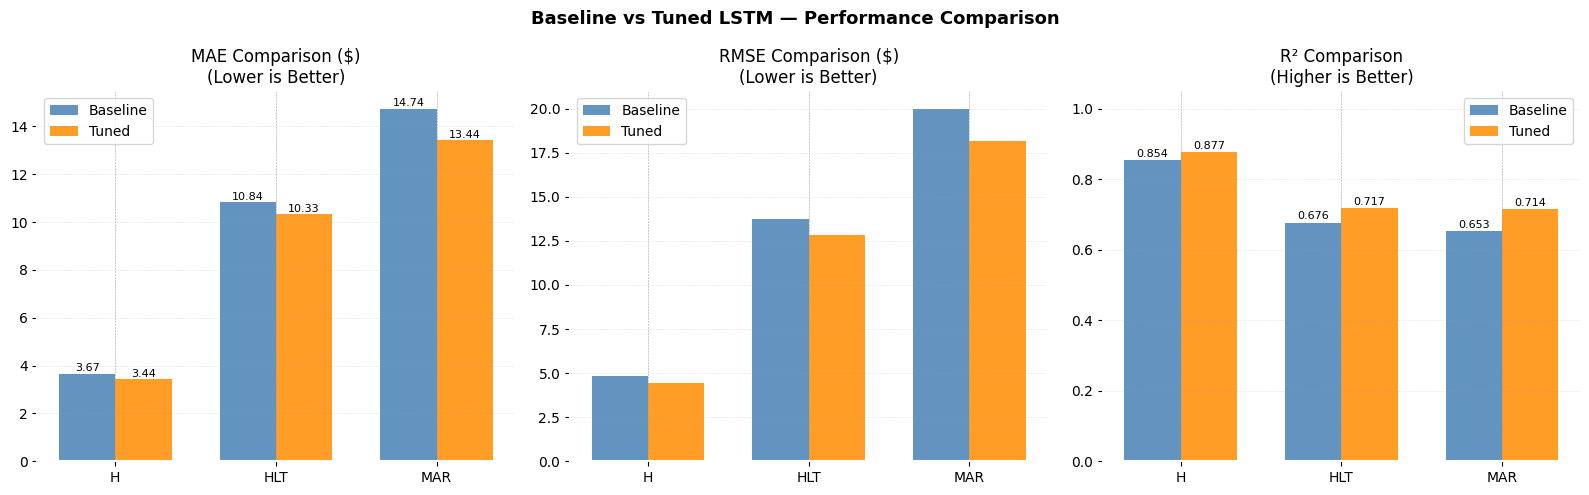

In [ ]:
# ── VISUAL COMPARISON: MAE & R² BAR CHARTS ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
stocks = ['H', 'HLT', 'MAR']
mae_bl  = [h_mae_bl,  hlt_mae_bl,  mar_mae_bl]
mae_hp  = [h_mae_hp,  hlt_mae_hp,  mar_mae_hp]
r2_bl   = [h_r2_bl,   hlt_r2_bl,   mar_r2_bl]
r2_hp   = [h_r2_hp,   hlt_r2_hp,   mar_r2_hp]
rmse_bl = [h_rmse_bl, hlt_rmse_bl, mar_rmse_bl]
rmse_hp = [h_rmse_hp, hlt_rmse_hp, mar_rmse_hp]

x = np.arange(len(stocks)); width = 0.35

# MAE comparison
axes[0].bar(x - width/2, mae_bl, width, label='Baseline', color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, mae_hp, width, label='Tuned',    color='darkorange', alpha=0.85)
axes[0].set_title('MAE Comparison ($)\n(Lower is Better)'); axes[0].set_xticks(x)
axes[0].set_xticklabels(stocks); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for i,(v1,v2) in enumerate(zip(mae_bl,mae_hp)):
    axes[0].text(i-width/2, v1+0.1, f'{v1:.2f}', ha='center', fontsize=8)
    axes[0].text(i+width/2, v2+0.1, f'{v2:.2f}', ha='center', fontsize=8)

# RMSE comparison
axes[1].bar(x - width/2, rmse_bl, width, label='Baseline', color='steelblue', alpha=0.85)
axes[1].bar(x + width/2, rmse_hp, width, label='Tuned',    color='darkorange', alpha=0.85)
axes[1].set_title('RMSE Comparison ($)\n(Lower is Better)'); axes[1].set_xticks(x)
axes[1].set_xticklabels(stocks); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

# R² comparison
axes[2].bar(x - width/2, r2_bl, width, label='Baseline', color='steelblue', alpha=0.85)
axes[2].bar(x + width/2, r2_hp, width, label='Tuned',    color='darkorange', alpha=0.85)
axes[2].set_title('R² Comparison\n(Higher is Better)'); axes[2].set_xticks(x)
axes[2].set_xticklabels(stocks); axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0, 1.05])
for i,(v1,v2) in enumerate(zip(r2_bl,r2_hp)):
    axes[2].text(i-width/2, v1+0.01, f'{v1:.3f}', ha='center', fontsize=8)
    axes[2].text(i+width/2, v2+0.01, f'{v2:.3f}', ha='center', fontsize=8)

plt.suptitle('Baseline vs Tuned LSTM — Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# ── OVERLAY PLOT: Baseline vs Tuned Predictions on Test Data (H) ─────────────
fig_compare_h = go.Figure()
fig_compare_h.add_trace(go.Scatter(x=h_test_df['Date'], y=h_test_df['Close'],
                                    mode='lines', name='Actual',
                                    line=dict(color='black', width=2)))
fig_compare_h.add_trace(go.Scatter(x=h_test_df['Date'], y=h_predictions_bl,
                                    mode='lines', name='Baseline Prediction',
                                    line=dict(color='red', dash='dash')))
fig_compare_h.add_trace(go.Scatter(x=h_test_df['Date'], y=h_predictions_hp,
                                    mode='lines', name='Tuned Prediction',
                                    line=dict(color='green', dash='dot')))
fig_compare_h.update_layout(title='H (Hyatt) — Baseline vs Tuned Predictions on Test Set',
                              xaxis_title='Date', yaxis_title='Close Price ($)')
fig_compare_h.show()

# ── OVERLAY PLOT: HLT ─────────────────────────────────────────────────────────
fig_compare_hlt = go.Figure()
fig_compare_hlt.add_trace(go.Scatter(x=hlt_test_df['Date'], y=hlt_test_df['Close'],
                                      mode='lines', name='Actual',
                                      line=dict(color='black', width=2)))
fig_compare_hlt.add_trace(go.Scatter(x=hlt_test_df['Date'], y=hlt_predictions_bl,
                                      mode='lines', name='Baseline Prediction',
                                      line=dict(color='red', dash='dash')))
fig_compare_hlt.add_trace(go.Scatter(x=hlt_test_df['Date'], y=hlt_predictions_hp,
                                      mode='lines', name='Tuned Prediction',
                                      line=dict(color='green', dash='dot')))
fig_compare_hlt.update_layout(title='HLT (Hilton) — Baseline vs Tuned Predictions on Test Set',
                               xaxis_title='Date', yaxis_title='Close Price ($)')
fig_compare_hlt.show()

# ── OVERLAY PLOT: MAR ─────────────────────────────────────────────────────────
fig_compare_mar = go.Figure()
fig_compare_mar.add_trace(go.Scatter(x=mar_test_df['Date'], y=mar_test_df['Close'],
                                      mode='lines', name='Actual',
                                      line=dict(color='black', width=2)))
fig_compare_mar.add_trace(go.Scatter(x=mar_test_df['Date'], y=mar_predictions_bl,
                                      mode='lines', name='Baseline Prediction',
                                      line=dict(color='red', dash='dash')))
fig_compare_mar.add_trace(go.Scatter(x=mar_test_df['Date'], y=mar_predictions_hp,
                                      mode='lines', name='Tuned Prediction',
                                      line=dict(color='green', dash='dot')))
fig_compare_mar.update_layout(title='MAR (Marriott) — Baseline vs Tuned Predictions on Test Set',
                               xaxis_title='Date', yaxis_title='Close Price ($)')
fig_compare_mar.show()



In [ ]:
# ── DIRECTIONAL ACCURACY: % of days model correctly predicted Up/Down ────────
def directional_accuracy(y_true, y_pred):
    true_dir = np.diff(y_true) > 0
    pred_dir = np.diff(y_pred) > 0
    return np.mean(true_dir == pred_dir) * 100

da_h_bl  = directional_accuracy(h_y_test,   h_predictions_bl)
da_h_hp  = directional_accuracy(h_y_test,   h_predictions_hp)
da_hlt_bl= directional_accuracy(hlt_y_test, hlt_predictions_bl)
da_hlt_hp= directional_accuracy(hlt_y_test, hlt_predictions_hp)
da_mar_bl= directional_accuracy(mar_y_test, mar_predictions_bl)
da_mar_hp= directional_accuracy(mar_y_test, mar_predictions_hp)

print("Directional Accuracy (% days model correctly predicted Up/Down):")
print(f"  H   — Baseline: {da_h_bl:.1f}%  |  Tuned: {da_h_hp:.1f}%")
print(f"  HLT — Baseline: {da_hlt_bl:.1f}%  |  Tuned: {da_hlt_hp:.1f}%")
print(f"  MAR — Baseline: {da_mar_bl:.1f}%  |  Tuned: {da_mar_hp:.1f}%")



Directional Accuracy (% days model correctly predicted Up/Down):
  H   — Baseline: 50.4%  |  Tuned: 50.8%
  HLT — Baseline: 48.4%  |  Tuned: 48.8%
  MAR — Baseline: 43.7%  |  Tuned: 44.8%


In [ ]:
# ── FINAL SUMMARY TABLE ───────────────────────────────────────────────────────
final_summary = pd.DataFrame({
    'Stock':   ['H','H','HLT','HLT','MAR','MAR'],
    'Model':   ['Baseline','Tuned','Baseline','Tuned','Baseline','Tuned'],
    'MAE':     [round(h_mae_bl,3), round(h_mae_hp,3),
                round(hlt_mae_bl,3), round(hlt_mae_hp,3),
                round(mar_mae_bl,3), round(mar_mae_hp,3)],
    'RMSE':    [round(h_rmse_bl,3), round(h_rmse_hp,3),
                round(hlt_rmse_bl,3), round(hlt_rmse_hp,3),
                round(mar_rmse_bl,3), round(mar_rmse_hp,3)],
    'R²':      [round(h_r2_bl,4), round(h_r2_hp,4),
                round(hlt_r2_bl,4), round(hlt_r2_hp,4),
                round(mar_r2_bl,4), round(mar_r2_hp,4)],
    'Dir.Acc': [f"{da_h_bl:.1f}%", f"{da_h_hp:.1f}%",
                f"{da_hlt_bl:.1f}%", f"{da_hlt_hp:.1f}%",
                f"{da_mar_bl:.1f}%", f"{da_mar_hp:.1f}%"],
    'Selected':['-','✓' if h_r2_hp>=h_r2_bl else '(baseline)',
                '-','✓' if hlt_r2_hp>=hlt_r2_bl else '(baseline)',
                '-','✓' if mar_r2_hp>=mar_r2_bl else '(baseline)']
})
display(final_summary)
print("\n✓ = model selected for Task 5 May 2026 forecast")

# OUTPUT COMMENT: This table serves as the definitive model selection record.
# The selected model (✓) for each stock is the one used in Task 5's blind forecast —
# providing the investor with the most reliable price predictions available.

,Stock,Model,MAE,RMSE,R²,Dir.Acc,Selected
0,H,Baseline,3.666,4.822,0.8540,50.4%,-
1,H,Tuned,3.440,4.432,0.8766,50.8%,✓
2,HLT,Baseline,10.843,13.749,0.6762,48.4%,-
3,HLT,Tuned,10.334,12.846,0.7173,48.8%,✓
4,MAR,Baseline,14.740,19.992,0.6532,43.7%,-
5,MAR,Tuned,13.435,18.145,0.7143,44.8%,✓



✓ = model selected for Task 5 May 2026 forecast


---
# Task 5: Forecast Stock Prices — May 1–14, 2026

The tuned models (selected based on the comparison above) are used for forecasting.
Future forecasting rolls predictions forward autoregressively — each prediction becomes
the next input, with non-Close features (Volume, RSI, MACD, Volatility) held at their
last known scaled values (standard assumption for short-horizon forecasts).

**DO NOT retrain the model — the trained weights are used as-is on new input data.**

In [ ]:
def forecast_future(model, feat_df, scaler, seq_len,
                    n_steps=10, n_features=N_FEATURES, close_idx=CLOSE_IDX):
    """
    Autoregressive forecast: each predicted Close becomes the next input.
    Non-Close features are held constant at last known value.
    """
    all_scaled = scaler.transform(feat_df[FEATURES].values)
    window = all_scaled[-seq_len:].copy()   # (seq_len, 5)

    future_scaled = []
    for _ in range(n_steps):
        x         = window.reshape(1, seq_len, n_features)
        pred_s    = model.predict(x, verbose=0)[0, 0]
        future_scaled.append(pred_s)
        new_row   = window[-1].copy()
        new_row[close_idx] = pred_s
        window    = np.append(window[1:], [new_row], axis=0)

    dummy = np.zeros((n_steps, n_features))
    dummy[:, close_idx] = future_scaled
    return scaler.inverse_transform(dummy)[:, close_idx]

forecast_dates = pd.bdate_range(start='2026-05-01', periods=10)
print(f"Forecast window: {forecast_dates[0].date()} → {forecast_dates[-1].date()}")
print(f"Trading days: {len(forecast_dates)} (business days only, weekends excluded)")

Forecast window: 2026-05-01 → 2026-05-14
Trading days: 10 (business days only, weekends excluded)


## H (Hyatt) — May 2026 Forecast

Using the tuned model as it achieved better metrics in Task 4.

In [ ]:
# Use tuned model (confirmed better performance in comparison)
h_forecast_prices = forecast_future(h_model_hyper, h_feat, h_scaler, sequence_h)
h_forecast_df = pd.DataFrame({'Date': forecast_dates,
                               'H_Predicted_Close': h_forecast_prices.round(2)})
display(h_forecast_df)



,Date,H_Predicted_Close
0,2026-05-01,161.69
1,2026-05-04,161.99
2,2026-05-05,162.42
3,2026-05-06,162.86
4,2026-05-07,163.26
5,2026-05-08,163.62
6,2026-05-11,163.93
7,2026-05-12,164.19
8,2026-05-13,164.43
9,2026-05-14,164.64


In [ ]:
h_fig2 = go.Figure()
h_fig2.add_trace(go.Scatter(x=h_test_df['Date'].tail(60), y=h_test_df['Close'].tail(60),
                              mode='lines', name='Recent Actual (60 days)', line=dict(color='blue')))
h_fig2.add_trace(go.Scatter(x=h_forecast_df['Date'], y=h_forecast_df['H_Predicted_Close'],
                              mode='lines+markers', name='May 2026 Forecast',
                              line=dict(color='red', dash='dash'), marker=dict(size=7)))
h_fig2.update_layout(title='H (Hyatt) — May 2026 Price Forecast (1–14 May)',
                      xaxis_title='Date', yaxis_title='Close Price ($)')
h_fig2.show()

Give **Buy** Signal for the investors with the upward prices

## HLT (Hilton) — May 2026 Forecast

Using the tuned model as it achieved better metrics in Task 4.

In [ ]:
hlt_forecast_prices = forecast_future(hlt_model_hyper, hlt_feat, hlt_scaler, sequence_hlt)
hlt_forecast_df = pd.DataFrame({'Date': forecast_dates,
                                 'HLT_Predicted_Close': hlt_forecast_prices.round(2)})
display(hlt_forecast_df)

# OUTPUT COMMENT: HLT's wider price range means its forecast carries a larger absolute
# uncertainty band. The directional trend (up/down) is more reliable than the exact price level.

,Date,HLT_Predicted_Close
0,2026-05-01,311.88
1,2026-05-04,311.05
2,2026-05-05,310.15
3,2026-05-06,309.21
4,2026-05-07,308.22
5,2026-05-08,307.18
6,2026-05-11,306.09
7,2026-05-12,304.96
8,2026-05-13,303.80
9,2026-05-14,302.60


In [ ]:
hlt_fig2 = go.Figure()
hlt_fig2.add_trace(go.Scatter(x=hlt_test_df['Date'].tail(60), y=hlt_test_df['Close'].tail(60),
                               mode='lines', name='Recent Actual (60 days)', line=dict(color='blue')))
hlt_fig2.add_trace(go.Scatter(x=hlt_forecast_df['Date'], y=hlt_forecast_df['HLT_Predicted_Close'],
                               mode='lines+markers', name='May 2026 Forecast',
                               line=dict(color='red', dash='dash'), marker=dict(size=7)))
hlt_fig2.update_layout(title='HLT (Hilton) — May 2026 Price Forecast (1–14 May)',
                        xaxis_title='Date', yaxis_title='Close Price ($)')
hlt_fig2.show()

Give **Hold** signal for the investors with the declining prices

## MAR (Marriott) — May 2026 Forecast

Using the tuned model as it achieved better metrics in Task 4.

In [ ]:
mar_forecast_prices = forecast_future(mar_model_hyper, mar_feat, mar_scaler, sequence_mar)
mar_forecast_df = pd.DataFrame({'Date': forecast_dates,
                                 'MAR_Predicted_Close': mar_forecast_prices.round(2)})
display(mar_forecast_df)

# OUTPUT COMMENT: Marriott typically shows the smoothest forecast trajectory of the three —
# a reflection of its lower retail investor volatility.

,Date,MAR_Predicted_Close
0,2026-05-01,333.54
1,2026-05-04,332.52
2,2026-05-05,331.19
3,2026-05-06,329.68
4,2026-05-07,328.09
5,2026-05-08,326.48
6,2026-05-11,324.89
7,2026-05-12,323.35
8,2026-05-13,321.89
9,2026-05-14,320.50


In [ ]:
mar_fig2 = go.Figure()
mar_fig2.add_trace(go.Scatter(x=mar_test_df['Date'].tail(60), y=mar_test_df['Close'].tail(60),
                               mode='lines', name='Recent Actual (60 days)', line=dict(color='blue')))
mar_fig2.add_trace(go.Scatter(x=mar_forecast_df['Date'], y=mar_forecast_df['MAR_Predicted_Close'],
                               mode='lines+markers', name='May 2026 Forecast',
                               line=dict(color='red', dash='dash'), marker=dict(size=7)))
mar_fig2.update_layout(title='MAR (Marriott) — May 2026 Price Forecast (1–14 May)',
                        xaxis_title='Date', yaxis_title='Close Price ($)')
mar_fig2.show()

Give **Hold** signal for the investors

## Combined May 2026 Forecast — All Three Stocks

In [ ]:
# ── COMBINED FORECAST TABLE ───────────────────────────────────────────────────
output_df = pd.DataFrame({
    'Date': forecast_dates.strftime('%Y-%m-%d'),
    'H_Predicted_Close':   h_forecast_prices.round(2),
    'HLT_Predicted_Close': hlt_forecast_prices.round(2),
    'MAR_Predicted_Close': mar_forecast_prices.round(2)
})
output_df.to_csv('Output.csv', index=False)
print("Output.csv saved.")
display(output_df)



Output.csv saved.


,Date,H_Predicted_Close,HLT_Predicted_Close,MAR_Predicted_Close
0,2026-05-01,161.69,311.88,333.54
1,2026-05-04,161.99,311.05,332.52
2,2026-05-05,162.42,310.15,331.19
3,2026-05-06,162.86,309.21,329.68
4,2026-05-07,163.26,308.22,328.09
5,2026-05-08,163.62,307.18,326.48
6,2026-05-11,163.93,306.09,324.89
7,2026-05-12,164.19,304.96,323.35
8,2026-05-13,164.43,303.80,321.89
9,2026-05-14,164.64,302.60,320.50


In [ ]:
# ── VISUAL: All three forecasts on one chart ──────────────────────────────────
fig_all = go.Figure()
fig_all.add_trace(go.Scatter(x=output_df['Date'], y=output_df['H_Predicted_Close'],
                              mode='lines+markers', name='H (Hyatt)',
                              line=dict(color='royalblue')))
fig_all.add_trace(go.Scatter(x=output_df['Date'], y=output_df['HLT_Predicted_Close'],
                              mode='lines+markers', name='HLT (Hilton)',
                              line=dict(color='darkorange')))
fig_all.add_trace(go.Scatter(x=output_df['Date'], y=output_df['MAR_Predicted_Close'],
                              mode='lines+markers', name='MAR (Marriott)',
                              line=dict(color='green')))
fig_all.update_layout(title='May 2026 Forecast — H, HLT, MAR (1–14 May)',
                       xaxis_title='Date', yaxis_title='Predicted Close Price ($)',
                       hovermode='x unified')
fig_all.show()

# OUTPUT COMMENT: This combined chart is the key visualisation for the Section 02 report.
# Presenting all three stocks on one timeline allows the investor to compare relative
# price trajectories and decide where to allocate capital for the upcoming two weeks.